<a href="https://colab.research.google.com/github/alxmzr/Colab/blob/main/WIN_DASH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--2026-05-06 07:59:01--  http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz
Resolving prdownloads.sourceforge.net (prdownloads.sourceforge.net)... 104.18.13.149, 104.18.12.149, 2606:4700::6812:c95, ...
Connecting to prdownloads.sourceforge.net (prdownloads.sourceforge.net)|104.18.13.149|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: http://downloads.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz [following]
--2026-05-06 07:59:01--  http://downloads.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz
Resolving downloads.sourceforge.net (downloads.sourceforge.net)... 104.18.12.149, 104.18.13.149, 2606:4700::6812:d95, ...
Reusing existing connection to prdownloads.sourceforge.net:80.
HTTP request sent, awaiting response... 302 Found
Location: http://cytranet-dal.dl.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz?viasf=1&fid=ddf25950915ad5b3 [following]
--2026-05-06 07:59:01--

/tmp/ipykernel_9764/2362605973.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('BTC-USD', period='1y', interval='1d')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_9764/2362605973.py:31: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df['Position'] = df['Signal'].replace(0, method='ffill').shift(1)


Итоговая доходность стратегии: -23.63%
Доходность Buy & Hold: -15.96%


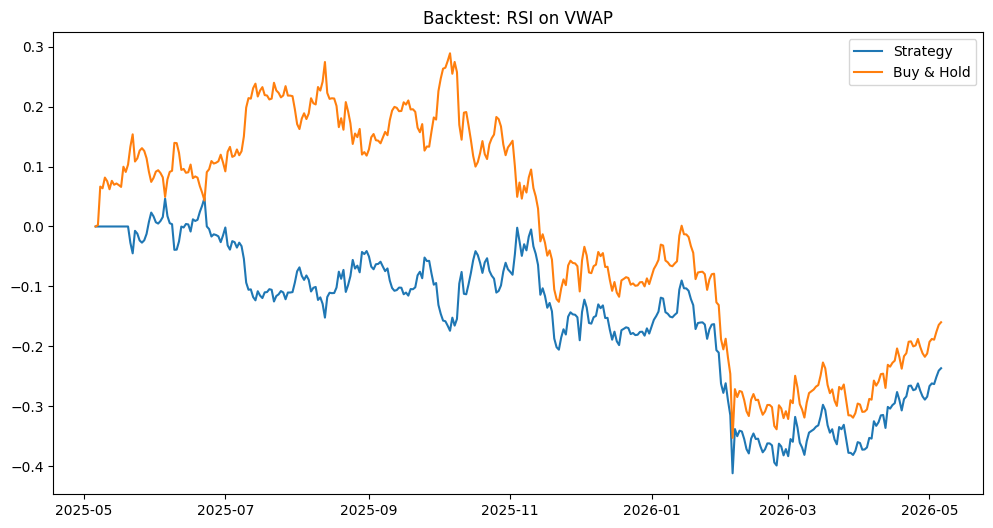

In [8]:
!wget http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz
!tar -xzvf ta-lib-0.4.0-src.tar.gz
%cd ta-lib
!./configure --prefix=/usr
!make
!make install
!pip install Ta-Lib
%cd /content

import yfinance as yf
import talib as ta
import pandas as pd
import numpy as np

# 1. Download data
data = yf.download('BTC-USD', period='1y', interval='1d')
df = data.copy()

# 2. Calculate VWAP and RSI-VWAP
tp = (df['High'] + df['Low'] + df['Close']) / 3
df['VWAP'] = ((tp * df['Volume']).cumsum()) / df['Volume'].cumsum()
df['RSI_VWAP'] = ta.RSI(df['VWAP'], timeperiod=14)

# 3. Strategy Logic (Buy < 30, Sell > 70)
df['Signal'] = 0
df.loc[df['RSI_VWAP'] < 30, 'Signal'] = 1  # Buy Signal
df.loc[df['RSI_VWAP'] > 70, 'Signal'] = -1 # Sell Signal

# 4. Backtest simulation
df['Returns'] = df['Close'].pct_change()
df['Position'] = df['Signal'].replace(0, method='ffill').shift(1)
df['Strategy_Returns'] = df['Returns'] * df['Position']

# 5. Performance Metrics
cum_returns = (1 + df['Strategy_Returns'].fillna(0)).cumprod() - 1
hold_returns = (1 + df['Returns'].fillna(0)).cumprod() - 1

print(f"Итоговая доходность стратегии: {cum_returns.iloc[-1]*100:.2f}%")
print(f"Доходность Buy & Hold: {hold_returns.iloc[-1]*100:.2f}%")

import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(cum_returns, label='Strategy')
plt.plot(hold_returns, label='Buy & Hold')
plt.title('Backtest: RSI on VWAP')
plt.legend()
plt.show()

In [5]:
# !pip install yfinance
# !pip install ta --upgrade
# !pip install mplfinance
# !pip install TA-Lib

In [6]:
import yfinance as yf
import talib as ta
import matplotlib.pyplot as plt

# Initial inputs
Act_RSI_VWAP = True
RSI_VWAP_length = 10
RSI_VWAP_overSold = 30
RSI_VWAP_overBought = 70

# RSI with VWAP as source
data = yf.download('BTC-USD', period='3d')

# Calculate VWAP
tp = (data['High'] + data['Low'] + data['Close']) / 3
vwap = ((tp * data['Volume']).cumsum()) / data['Volume'].cumsum()
RSI_VWAP = ta.RSI(vwap, timeperiod=RSI_VWAP_length)

# Plotting, overlay=false
r = RSI_VWAP
h1 = RSI_VWAP_overBought
h2 = RSI_VWAP_overSold

fig, ax = plt.subplots()
ax.plot(r)
ax.axhline(h1, color='red')
ax.axhline(h2, color='green')
plt.show()


ModuleNotFoundError: No module named 'talib'

In [ ]:
import yfinance as yf
import talib as ta
import matplotlib.pyplot as plt
from mplfinance.original_flavor import candlestick_ohlc
import matplotlib.dates as mdates
import pandas as pd

# Initial inputs
Act_RSI_VWAP = True
RSI_VWAP_length = 10
RSI_VWAP_overSold = 40
RSI_VWAP_overBought = 60

# RSI with VWAP as source
data = yf.download('BTC-USD', period='30d')
df = pd.DataFrame(data)
df['Date'] = df.index.map(mdates.date2num)

# Calculate VWAP
tp = (data['High'] + data['Low'] + data['Close']) / 3
vwap = ((tp * data['Volume']).cumsum()) / data['Volume'].cumsum()
RSI_VWAP = ta.RSI(vwap, timeperiod=RSI_VWAP_length)

# Plotting, overlay=false
r = RSI_VWAP
h1 = RSI_VWAP_overBought
h2 = RSI_VWAP_overSold

# Create a new DataFrame for candlestick chart
# Create a new DataFrame for candlestick chart
df_ohlc = df[['Open', 'High', 'Low', 'Close']].copy()
df_ohlc = df_ohlc.reset_index()
df_ohlc['Date'] = df_ohlc['Date'].map(mdates.date2num)


# Create subplots
fig, ax = plt.subplots()

# Plot candlestick chart
candlestick_ohlc(ax, df_ohlc.values, width=0.6, colorup='green', colordown='red', alpha=0.8)

# Add RSI_VWAP plot
ax.plot(df.index, r, label='RSI_VWAP')
ax.axhline(h1, color='red', label='Overbought')
ax.axhline(h2, color='green', label='Oversold')

# Set chart style
ax.xaxis_date()
ax.grid(True)
ax.legend()

# Show the chart
plt.show()


In [7]:
import yfinance as yf
import talib as ta
import matplotlib.pyplot as plt
from mplfinance.original_flavor import candlestick_ohlc
import matplotlib.dates as mdates
import pandas as pd

# Initial inputs
Act_RSI_VWAP = True
RSI_VWAP_length = 10
RSI_VWAP_overSold = 30
RSI_VWAP_overBought = 70

# RSI with VWAP as source
data = yf.download('BTC-USD', period='30d')
df = pd.DataFrame(data)
df['Date'] = df.index.map(mdates.date2num)

# Calculate VWAP
tp = (data['High'] + data['Low'] + data['Close']) / 3
vwap = ((tp * data['Volume']).cumsum()) / data['Volume'].cumsum()
RSI_VWAP = ta.RSI(vwap, timeperiod=RSI_VWAP_length)

# Plotting, overlay=false
r = RSI_VWAP
h1 = RSI_VWAP_overBought
h2 = RSI_VWAP_overSold

# Create a new DataFrame for candlestick chart
df_ohlc = df[['Open', 'High', 'Low', 'Close']].copy()
df_ohlc = df_ohlc.reset_index()
df_ohlc['Date'] = df_ohlc['Date'].map(mdates.date2num)

# Create subplots
fig, ax = plt.subplots()

# Plot candlestick chart
candlestick_ohlc(ax, df_ohlc.values, width=0.6, colorup='green', colordown='red', alpha=0.8)

# Add RSI_VWAP plot
ax.plot(df.index, r, label='RSI_VWAP')
ax.axhline(h1, color='red', label='Overbought')
ax.axhline(h2, color='green', label='Oversold')

# Set chart style
ax.xaxis_date()
ax.grid(True)
ax.legend()

# Show the chart
plt.show()


ModuleNotFoundError: No module named 'talib'

In [ ]:
import yfinance as yf
import talib as ta
import matplotlib.pyplot as plt
from mplfinance.original_flavor import candlestick_ohlc
import matplotlib.dates as mdates
import pandas as pd

# Initial inputs
Act_RSI_VWAP = True
RSI_VWAP_length = 10
RSI_VWAP_overSold = 20
RSI_VWAP_overBought = 80

# RSI with VWAP as source
data = yf.download('BTC-USD', period='30d')
df = pd.DataFrame(data)
df['Date'] = df.index.map(mdates.date2num)

# Calculate VWAP
tp = (data['High'] + data['Low'] + data['Close']) / 3
vwap = ((tp * data['Volume']).cumsum()) / data['Volume'].cumsum()
RSI_VWAP = ta.RSI(vwap, timeperiod=RSI_VWAP_length)

# Plotting, overlay=false
r = RSI_VWAP
h1 = RSI_VWAP_overBought
h2 = RSI_VWAP_overSold

# Create a new DataFrame for candlestick chart
df_ohlc = df[['Date', 'Open', 'High', 'Low', 'Close']].copy()

# Create subplots
fig, ax = plt.subplots()

# Plot candlestick chart
candlestick_ohlc(ax, df_ohlc.values, width=0.6, colorup='green', colordown='red', alpha=0.8)

# Add RSI_VWAP plot
ax.plot(df.index, r, label='RSI_VWAP', color='purple')
ax.axhline(h1, color='red', label='Overbought')
ax.axhline(h2, color='green', label='Oversold')
ax.set_ylim([0,100]) # Set the y-axis limits
ax.text(df.index[0], h1-5, 'Overbought', color='red')
ax.text(df.index[0], h2+5, 'Oversold', color='green')

# Set chart style
ax.xaxis_date()
ax.grid(True)
ax.legend()

# Show the chart
plt.show()

# Create subplots
fig, ax = plt.subplots()

# Plot candlestick chart
candlestick_ohlc(ax, df_ohlc.values, width=0.6, colorup='green', colordown='red', alpha=0.8)

# Add RSI_VWAP plot
ax.plot(df.index, r, label='RSI_VWAP')
ax.axhline(h1, color='red', label='Overbought')
ax.axhline(h2, color='green', label='Oversold')

# Set chart style
ax.xaxis_date()
ax.grid(True)
ax.legend()

# Show the chart
plt.show()



In [ ]:
import yfinance as yf
import talib as ta
import matplotlib.pyplot as plt
from mplfinance.original_flavor import candlestick_ohlc
import matplotlib.dates as mdates
import pandas as pd

# Initial inputs
Act_RSI_VWAP = True
RSI_VWAP_length = 10
RSI_VWAP_overSold = 20 / 100
RSI_VWAP_overBought = 80 / 100

# RSI with VWAP as source
data = yf.download('BTC-USD', period='30d')
df = pd.DataFrame(data)
df['Date'] = df.index.map(mdates.date2num)

# Calculate VWAP
tp = (data['High'] + data['Low'] + data['Close']) / 3
vwap = ((tp * data['Volume']).cumsum()) / data['Volume'].cumsum()
RSI_VWAP = ta.RSI(vwap, timeperiod=RSI_VWAP_length)

# Create a new DataFrame for candlestick chart
df_ohlc = df[['Date', 'Open', 'High', 'Low', 'Close']].copy()

# Create subplots
fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True, figsize=(12, 8))

# Plot candlestick chart
candlestick_ohlc(ax1, df_ohlc.values, width=0.6, colorup='green', colordown='red', alpha=0.8)

# Set chart style for candlestick chart
ax1.xaxis_date()
ax1.grid(True)

# Add RSI_VWAP plot
ax2.plot(df.index, RSI_VWAP, label='RSI_VWAP')
ax2.axhline(RSI_VWAP_overBought, color='red', label='Overbought')
ax2.axhline(RSI_VWAP_overSold, color='green', label='Oversold')

# Set chart style for RSI_VWAP chart
ax2.grid(True)
ax2.legend()

# Show the chart
plt.show()


In [ ]:
import yfinance as yf
import talib as ta
import matplotlib.pyplot as plt
from mplfinance.original_flavor import candlestick_ohlc
import matplotlib.dates as mdates
import pandas as pd

# Initial inputs
Act_RSI_VWAP = True
RSI_VWAP_length = 10
RSI_VWAP_overSold = 20 /100
RSI_VWAP_overBought = 80 /100

# RSI with VWAP as source
data = yf.download('BTC-USD', period='30d')
df = pd.DataFrame(data)
df['Date'] = df.index.map(mdates.date2num)

# Calculate VWAP
tp = (data['High'] + data['Low'] + data['Close']) / 3
vwap = ((tp * data['Volume']).cumsum()) / data['Volume'].cumsum()
RSI_VWAP = ta.RSI(vwap, timeperiod=RSI_VWAP_length)

# Create a new DataFrame for candlestick chart
df_ohlc = df[['Open', 'High', 'Low', 'Close']].copy()
df_ohlc = df_ohlc.reset_index()
df_ohlc['Date'] = df_ohlc['Date'].map(mdates.date2num)

# Create subplots
fig, ax = plt.subplots()

# Plot candlestick chart
candlestick_ohlc(ax, df_ohlc.values, width=0.6, colorup='green', colordown='red', alpha=0.8)

# Add RSI_VWAP plot
ax.plot(df.index, r, label='RSI_VWAP')
ax.axhline(h1, color='red', label='Overbought')
ax.axhline(h2, color='green', label='Oversold')

# Set chart style
ax.xaxis_date()
ax.grid(True)
ax.legend()

# Show the chart
plt.show()
